In [1]:

# Install required packages (idempotent, safe to re-run)
import sys
!{sys.executable} -m pip install --quiet lightgbm scikit-learn pandas numpy matplotlib joblib imblearn

# EXP 3 G Sampling Experiment

Reliability check for `base`, `cw`, `smote`, `smote+cw`, `smotenc`, and `smote+nc` using the same EXP3 preprocessing bundle used by the app.
Focus: detect physiologically/medically impossible synthetic patients.

In [2]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.utils import resample
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)

In [ ]:
# -- Utility helpers (mirrors Main_2015_Training_Core + EXP3-B) --------------

def _find_col(columns, aliases):
    lc = {c.lower(): c for c in columns}
    for a in aliases:
        if a.lower() in lc:
            return lc[a.lower()]
    for c in columns:
        if any(a.lower() in c.lower() for a in aliases):
            return c
    return None

def _to_num(s):
    return pd.to_numeric(s, errors='coerce').replace([9, 99, 888888, 999999], np.nan)

def _build_smoking_level(df_):
    sl = _find_col(df_.columns, ['smoking_level'])
    if sl:
        return _to_num(df_[sl]).clip(0, 3).astype(float), [sl]
    ss  = _find_col(df_.columns, ['smoke_status'])
    cs  = _find_col(df_.columns, ['current_smoking', 'currentsmoking'])
    es  = _find_col(df_.columns, ['ever_smk'])
    used, out = [], pd.Series(np.nan, index=df_.index, dtype=float)
    if ss:
        status = _to_num(df_[ss]); used.append(ss)
        out[status == 0] = 0; out[status == 2] = 1; out[status == 1] = 2
        if cs:
            cur = _to_num(df_[cs]); used.append(cs)
            out[(status == 1) & (cur == 3)] = 3
        return out, used
    if cs:
        cur = _to_num(df_[cs]); used.append(cs)
        out[cur == 0] = 0; out[cur.isin([1, 2])] = 2; out[cur == 3] = 3
        return out, used
    if es:
        ever = _to_num(df_[es]); used.append(es)
        out[ever == 0] = 0; out[ever > 0] = 1
        return out, used
    return None, []

def _build_alcohol_level(df_):
    al = _find_col(df_.columns, ['alcohol_level'])
    if al:
        return _to_num(df_[al]).clip(0, 3).astype(float), [al]
    as_ = _find_col(df_.columns, ['alcohol_status'])
    bg  = _find_col(df_.columns, ['binge_drink', 'binge_drinking'])
    ca  = _find_col(df_.columns, ['con_alcohol'])
    d30 = _find_col(df_.columns, ['drnk_30days'])
    ae  = _find_col(df_.columns, ['alcohol'])
    used, out = [], pd.Series(np.nan, index=df_.index, dtype=float)
    if as_:
        status = _to_num(df_[as_]); used.append(as_)
        out[status == 0] = 0; out[status == 2] = 1; out[status == 1] = 2
        if bg:
            binge = _to_num(df_[bg]); used.append(bg)
            out[(status == 1) & (binge == 1)] = 3
        return out, used
    out[:] = 0
    if ae:
        ever = _to_num(df_[ae]);   used.append(ae);   out[ever > 0] = 1
    if ca:
        cur  = _to_num(df_[ca]);   used.append(ca);   out[cur == 1] = np.maximum(out[cur == 1], 2)
    if d30:
        d    = _to_num(df_[d30]);  used.append(d30);  out[d == 1]   = np.maximum(out[d == 1], 2)
    if bg:
        b    = _to_num(df_[bg]);   used.append(bg);   out[b == 1]   = 3
    return (out, used) if used else (None, [])

def _build_bmi(df_):
    w = _find_col(df_.columns, ['weight'])
    h = _find_col(df_.columns, ['height'])
    if not w or not h:
        return None, []
    wt = pd.to_numeric(df_[w], errors='coerce')
    ht = pd.to_numeric(df_[h], errors='coerce')
    if pd.notna(ht.median()) and float(ht.median()) > 3.0:
        ht = ht / 100.0
    return (wt / ht**2).replace([np.inf, -np.inf], np.nan).astype(float), [w, h]

def _build_whr(df_):
    wc = _find_col(df_.columns, ['waist'])
    hc = _find_col(df_.columns, ['hip'])
    if not wc or not hc:
        return None, []
    waist = pd.to_numeric(df_[wc], errors='coerce')
    hip   = pd.to_numeric(df_[hc], errors='coerce').replace(0, np.nan)
    return (waist / hip).replace([np.inf, -np.inf], np.nan).astype(float), [wc, hc]

# -- Load fixed merged dataset from training subfolder -------------------------
CWD = Path.cwd()
if (CWD / 'training').exists():
    ROOT = CWD
elif (CWD / 'FINAL' / 'training').exists():
    ROOT = CWD / 'FINAL'
elif (CWD.parent / 'training').exists():
    ROOT = CWD.parent
else:
    ROOT = CWD

DATA_PATH = ROOT / 'training' / 'merged_clinical_leftjoin.csv'
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Required dataset not found: {DATA_PATH}')

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Using merged dataset: {DATA_PATH}')
print(f'Final merged shape : {df.shape}')

# -- Target engineering (Hypertension from SBP/DBP, mirrors Main_2015_Training_Core) --
sbp_col = _find_col(df.columns, ['ave_sbp', 'sbp', 'systolic', 'sysbp'])
dbp_col = _find_col(df.columns, ['ave_dbp', 'dbp', 'diastolic', 'diabp'])

if sbp_col and dbp_col:
    sbp = pd.to_numeric(df[sbp_col], errors='coerce')
    dbp = pd.to_numeric(df[dbp_col], errors='coerce')
    df['Hypertension'] = ((sbp >= 140) | (dbp >= 90)).fillna(False).astype(int)
    TARGET_COL = 'Hypertension'
    print(f'Target created from {sbp_col}, {dbp_col}  (>=140/90 rule)')
else:
    TARGET_COL = _find_col(df.columns, ['hypertension', 'htn', 'target', 'label', 'outcome'])
    if TARGET_COL is None:
        raise ValueError(f'Cannot derive target. Columns: {list(df.columns[:30])}')
    print(f'Target column found : {TARGET_COL}')

df = df.dropna(subset=[TARGET_COL]).copy()
print('Class balance:', df[TARGET_COL].value_counts(normalize=True).round(3).to_dict())

# -- Feature engineering (mirrors EXP3-B) --------------------------------------
X_raw = df.drop(columns=[TARGET_COL]).copy()
y     = df[TARGET_COL].astype(int).copy()

smk, smk_src = _build_smoking_level(X_raw)
if smk is not None:
    X_raw['fe_smoking_level'] = smk

alc, alc_src = _build_alcohol_level(X_raw)
if alc is not None:
    X_raw['fe_alcohol_level'] = alc

bmi, bmi_src = _build_bmi(X_raw)
if bmi is not None:
    X_raw['bmi'] = bmi

whr, whr_src = _build_whr(X_raw)
if whr is not None:
    X_raw['whr'] = whr

# -- Drop non-predictive / raw source columns (mirrors EXP3-B manual_non_predictive) --
DROP_ALWAYS = [
    sbp_col, dbp_col,
    'height', 'weight', 'waist', 'hip',
    'enns_year', 'hhnum', 'member_code',
    'regcode', 'provcode', 'psc', 'csc', 'rhc', 'psurec', 'strrec',
    'wgts', 'finalwgt', 'finalwgt1', 'finalwgt4',
    'rep_natl', 'rep_prov', 'ms_psucode', 'wrkplace',
    'interview_status', 'intdate', 'enumcode',
    'alcohol', 'con_alcohol', 'drnk_30days', 'drnk_30d_num', 'alcohol_status',
    'binge_drinking', 'current_smoking', 'ever_smk', 'smoke_status', 'smoking_level', 'alcohol_level',
]
DROP_ALWAYS += list(set(bmi_src + whr_src + smk_src + alc_src))
lc_map = {c.lower(): c for c in X_raw.columns}
to_drop = sorted({lc_map[d.lower()] for d in DROP_ALWAYS if d and d.lower() in lc_map})
X_raw = X_raw.drop(columns=to_drop, errors='ignore')

# Deduplicate age/sex alias columns from anthro join
for _alias in ['age', 'sex']:
    _cands = [c for c in X_raw.columns if _alias in c.lower()]
    if len(_cands) > 1:
        _keep  = next((c for c in _cands if c.lower() == _alias), _cands[0])
        X_raw  = X_raw.drop(columns=[c for c in _cands if c != _keep], errors='ignore')

X = X_raw.copy()
print(f'Features: {X.shape[1]}  | Rows: {len(X)}  | Positives: {int(y.sum())}')

After dietary merge : (151189, 63)  keys=['hhnum']
After anthro merge  : (151189, 80)  keys=['hhnum', 'member_code']
Final merged shape  : (151189, 80)
Target created from Ave_SBP, Ave_DBP  (>=140/90 rule)
Class balance: {0: 0.848, 1: 0.152}
Features: 55  | Rows: 151189  | Positives: 22988


In [4]:
# ── EXP3-B style preprocessing: 3-way split + KNN impute + scale/OHE ─────────
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def _ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

def e3_fit_imputers(X_tr, num_cols, cat_cols):
    knn = KNNImputer(n_neighbors=5)
    if num_cols:
        knn.fit(X_tr[num_cols])
    cat_imp = None
    if cat_cols:
        cat_imp = SimpleImputer(strategy='most_frequent')
        cat_imp.fit(X_tr[cat_cols])
    return knn, cat_imp

def e3_impute(knn, cat_imp, X_df, num_cols, cat_cols):
    frames = []
    if num_cols:
        frames.append(pd.DataFrame(knn.transform(X_df[num_cols]), columns=num_cols, index=X_df.index))
    if cat_cols and cat_imp is not None:
        frames.append(pd.DataFrame(cat_imp.transform(X_df[cat_cols]), columns=cat_cols, index=X_df.index))
    return pd.concat(frames, axis=1) if frames else pd.DataFrame(index=X_df.index)

def e3_fit_enc_scaler(X_imp, num_cols, cat_cols):
    scaler = StandardScaler()
    ohe_enc = None
    if num_cols:
        scaler.fit(X_imp[num_cols])
    if cat_cols:
        ohe_enc = _ohe()
        ohe_enc.fit(X_imp[cat_cols].astype(str))
    return scaler, ohe_enc

def e3_encode(scaler, ohe_enc, X_imp, num_cols, cat_cols):
    parts = []
    if num_cols:
        parts.append(scaler.transform(X_imp[num_cols]))
    if cat_cols and ohe_enc is not None:
        parts.append(ohe_enc.transform(X_imp[cat_cols].astype(str)))
    return np.hstack(parts) if parts else np.empty((len(X_imp), 0))

# 3-way split: 60% train, 20% cal, 20% test (mirrors EXP3-B)
X_tr_raw, X_tmp_raw, y_train, y_tmp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)
X_cal_raw, X_test_raw, y_cal, y_test = train_test_split(
    X_tmp_raw, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp
)

# Detect numeric / categorical on training split

# Always treat these as categorical for SMOTENC, even if numeric
force_cat = ['fe_smoking_level', 'fe_alcohol_level']
# Try to find an ethnicity column (case-insensitive, partial match)
ethnicity_col = next((c for c in X_tr_raw.columns if 'ethnic' in c.lower()), None)
if ethnicity_col:
    force_cat.append(ethnicity_col)

e3_num_cols = X_tr_raw.select_dtypes(include=[np.number]).columns.tolist()
e3_cat_cols = [c for c in X_tr_raw.columns if c not in e3_num_cols or c in force_cat]
e3_num_cols = [c for c in e3_num_cols if c not in force_cat]

# Fit imputers and scalers on train only
knn_imp, cat_imp = e3_fit_imputers(X_tr_raw, e3_num_cols, e3_cat_cols)

X_tr_imp  = e3_impute(knn_imp, cat_imp, X_tr_raw,   e3_num_cols, e3_cat_cols)
X_cal_imp = e3_impute(knn_imp, cat_imp, X_cal_raw,  e3_num_cols, e3_cat_cols)
X_te_imp  = e3_impute(knn_imp, cat_imp, X_test_raw, e3_num_cols, e3_cat_cols)

scaler_e3, ohe_e3 = e3_fit_enc_scaler(X_tr_imp, e3_num_cols, e3_cat_cols)

# For SMOTENC: build ordinal-encoded train matrix (cat preserved as ordinal)
oe_sampling = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
if e3_cat_cols:
    Xc_ord = pd.DataFrame(
        oe_sampling.fit_transform(X_tr_imp[e3_cat_cols].astype(str)),
        columns=e3_cat_cols, index=X_tr_imp.index
    )
else:
    Xc_ord = pd.DataFrame(index=X_tr_imp.index)

X_train_sampling = pd.concat([X_tr_imp[e3_num_cols] if e3_num_cols else pd.DataFrame(index=X_tr_imp.index), Xc_ord], axis=1)
feature_cols_sampling = list(X_train_sampling.columns)
cat_idx = list(range(len(e3_num_cols), len(e3_num_cols) + len(e3_cat_cols)))

print(pd.DataFrame({
    'Split': ['Train', 'Cal', 'Test'],
    'N':     [len(y_train), len(y_cal), len(y_test)],
    'Pos%':  [f"{y_train.mean()*100:.1f}", f"{y_cal.mean()*100:.1f}", f"{y_test.mean()*100:.1f}"],
}).to_string(index=False))
print(f'\nNumeric: {len(e3_num_cols)} | Categorical: {len(e3_cat_cols)}')
print(f'Sampling matrix shape: {X_train_sampling.shape} | cat_idx for SMOTENC: {len(cat_idx)}')

Split     N Pos%
Train 90713 15.2
  Cal 30238 15.2
 Test 30238 15.2

Numeric: 52 | Categorical: 3
Sampling matrix shape: (90713, 55) | cat_idx for SMOTENC: 3


In [5]:
def impossible_flags(df_sample: pd.DataFrame) -> pd.Series:
    f = pd.Series(False, index=df_sample.index)

    if 'age' in df_sample.columns:
        f |= (df_sample['age'] < 18) | (df_sample['age'] > 120)
    if 'sex' in df_sample.columns:
        f |= ~df_sample['sex'].round().isin([1, 2])
    if 'height' in df_sample.columns:
        f |= (df_sample['height'] <= 0) | (df_sample['height'] > 260)
    if 'weight' in df_sample.columns:
        f |= (df_sample['weight'] <= 0) | (df_sample['weight'] > 350)
    if 'waist' in df_sample.columns:
        f |= (df_sample['waist'] <= 0) | (df_sample['waist'] > 200)
    if 'hip' in df_sample.columns:
        f |= (df_sample['hip'] <= 0) | (df_sample['hip'] > 220)
    if 'BMI' in df_sample.columns:
        f |= (df_sample['BMI'] < 10) | (df_sample['BMI'] > 50)
    if 'bmi' in df_sample.columns:
        f |= (df_sample['bmi'] < 10) | (df_sample['bmi'] > 50)
    if 'whr' in df_sample.columns:
        f |= (df_sample['whr'] < 0.4) | (df_sample['whr'] > 2.0)

    nonneg_prefixes = ('Total_', 'fg', 'epwt_fg')
    for c in df_sample.columns:
        if c.startswith(nonneg_prefixes):
            f |= (pd.to_numeric(df_sample[c], errors='coerce') < 0)

    return f.fillna(True)

def resample_method(name: str, Xs: pd.DataFrame, ys: pd.Series) -> tuple[pd.DataFrame, pd.Series]:
    if name in {'base', 'cw'}:
        return Xs.copy(), ys.copy()
    if name in {'smote', 'smote+cw'}:
        sampler = SMOTE(random_state=42, k_neighbors=5)
        Xr, yr = sampler.fit_resample(Xs, ys)
        return pd.DataFrame(Xr, columns=Xs.columns), pd.Series(yr)
    if name in {'smotenc', 'smote+nc'}:
        sampler = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=5)
        Xr, yr = sampler.fit_resample(Xs, ys)
        return pd.DataFrame(Xr, columns=Xs.columns), pd.Series(yr)
    raise ValueError(name)

In [6]:
methods = ['base', 'cw', 'smote', 'smote+cw', 'smotenc', 'smote+nc']
summary_rows = []
examples = {}

n_orig = len(X_train_sampling)

for m in methods:
    Xr, yr = resample_method(m, X_train_sampling, y_train)
    flags_all = impossible_flags(Xr)

    n_all = int(len(Xr))
    n_bad_all = int(flags_all.sum())

    # For over-sampling methods, imblearn appends synthetic rows after originals.
    n_syn = max(n_all - n_orig, 0)
    if n_syn > 0:
        flags_syn = flags_all.iloc[n_orig:]
        n_bad_syn = int(flags_syn.sum())
        syn_bad_pct = 100.0 * n_bad_syn / n_syn
        if n_bad_syn > 0:
            examples[m] = Xr.iloc[n_orig:].loc[flags_syn].head(5).copy()
    else:
        n_bad_syn = 0
        syn_bad_pct = np.nan

    summary_rows.append({
        'method': m,
        'rows_total': n_all,
        'rows_synthetic': n_syn,
        'positive_rate': float(np.mean(yr)),
        'impossible_all_rows': n_bad_all,
        'impossible_all_pct': (100.0 * n_bad_all / max(n_all, 1)),
        'impossible_synth_rows': n_bad_syn,
        'impossible_synth_pct': syn_bad_pct,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(['impossible_synth_pct', 'impossible_all_pct', 'method'], na_position='last').reset_index(drop=True)
summary_df

,method,rows_total,rows_synthetic,positive_rate,impossible_all_rows,impossible_all_pct,impossible_synth_rows,impossible_synth_pct
0,smote,153840,63127,0.500000,35225,22.897166,347,0.549686
1,smote+cw,153840,63127,0.500000,35225,22.897166,347,0.549686
2,smote+nc,153840,63127,0.500000,35230,22.900416,352,0.557606
3,smotenc,153840,63127,0.500000,35230,22.900416,352,0.557606
4,base,90713,0,0.152051,34878,38.448734,0,NaN
5,cw,90713,0,0.152051,34878,38.448734,0,NaN


In [7]:
from sklearn.metrics import roc_auc_score

def build_sampling_matrix(X_imp: pd.DataFrame) -> pd.DataFrame:
    if e3_cat_cols:
        Xc = pd.DataFrame(
            oe_sampling.transform(X_imp[e3_cat_cols].astype(str)),
            columns=e3_cat_cols,
            index=X_imp.index,
        )
    else:
        Xc = pd.DataFrame(index=X_imp.index)

    Xn = X_imp[e3_num_cols] if e3_num_cols else pd.DataFrame(index=X_imp.index)
    return pd.concat([Xn, Xc], axis=1)[feature_cols_sampling]

X_cal_sampling = build_sampling_matrix(X_cal_imp)
X_test_sampling = build_sampling_matrix(X_te_imp)

def make_lgbm(method_name: str) -> lgb.LGBMClassifier:
    params = dict(
        objective='binary',
        random_state=42,
        n_estimators=400,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.8,
        min_child_samples=20,
        reg_alpha=0.0,
        reg_lambda=0.0,
        verbosity=-1,
    )
    if method_name in {'cw', 'smote+cw'}:
        params['class_weight'] = 'balanced'

    # Try GPU first; fallback to CPU for environments without OpenCL/CUDA support.
    try:
        return lgb.LGBMClassifier(device='gpu', **params)
    except Exception:
        return lgb.LGBMClassifier(device='cpu', **params)

metric_rows = []
for m in methods:
    Xr, yr = resample_method(m, X_train_sampling, y_train)

    model = make_lgbm(m)
    try:
        model.fit(Xr, yr)
    except Exception:
        # If GPU fit fails at runtime, retry on CPU.
        model = lgb.LGBMClassifier(
            device='cpu',
            objective='binary',
            random_state=42,
            n_estimators=400,
            learning_rate=0.03,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.8,
            min_child_samples=20,
            reg_alpha=0.0,
            reg_lambda=0.0,
            verbosity=-1,
            class_weight='balanced' if m in {'cw', 'smote+cw'} else None,
        )
        model.fit(Xr, yr)

    proba = model.predict_proba(X_test_sampling)[:, 1]
    pred = (proba >= 0.5).astype(int)

    metric_rows.append({
        'method': m,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, proba),
    })

metrics_df = pd.DataFrame(metric_rows).sort_values('f1', ascending=False).reset_index(drop=True)
comparison_df = summary_df.merge(metrics_df, on='method', how='left')
comparison_df[['method', 'rows_synthetic', 'impossible_synth_pct', 'impossible_all_pct', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']].sort_values('f1', ascending=False)

,method,rows_synthetic,impossible_synth_pct,impossible_all_pct,accuracy,precision,recall,f1,roc_auc
5,cw,0,NaN,38.448734,0.729513,0.344558,0.863607,0.492586,0.853201
2,smote+nc,63127,0.557606,22.900416,0.840366,0.464396,0.326300,0.383289,0.849171
3,smotenc,63127,0.557606,22.900416,0.840366,0.464396,0.326300,0.383289,0.849170
0,smote,63127,0.549686,22.897166,0.841788,0.469945,0.318034,0.379346,0.849883
1,smote+cw,63127,0.549686,22.897166,0.841788,0.469945,0.318034,0.379346,0.849884
4,base,0,NaN,38.448734,0.851644,0.553110,0.125734,0.204892,0.853560


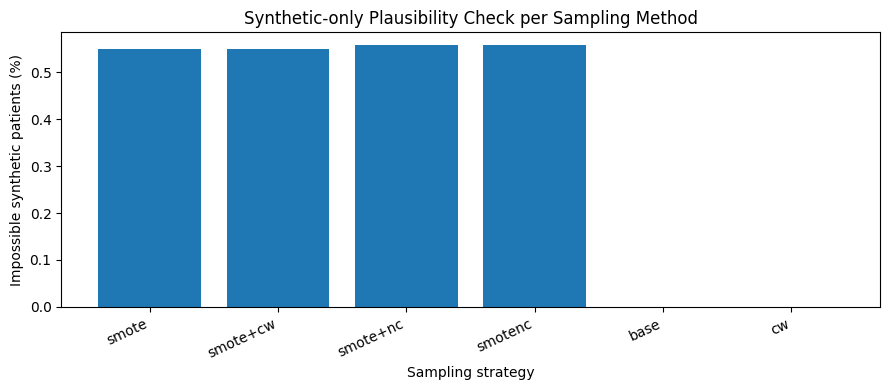

In [8]:
import matplotlib.pyplot as plt

plot_df = summary_df.copy()
plot_df['impossible_synth_pct_plot'] = plot_df['impossible_synth_pct'].fillna(0.0)

plt.figure(figsize=(9, 4))
plt.bar(plot_df['method'], plot_df['impossible_synth_pct_plot'])
plt.ylabel('Impossible synthetic patients (%)')
plt.xlabel('Sampling strategy')
plt.title('Synthetic-only Plausibility Check per Sampling Method')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

In [9]:
# Inspect first impossible examples per method (if any).
for m in methods:
    print('\n===', m, '===')
    if m not in examples:
        print('No impossible rows detected.')
    else:
        display(examples[m])


=== base ===
No impossible rows detected.

=== cw ===
No impossible rows detected.

=== smote ===


,sex,age,Total_Energy,fg6,fg7,fg8,fg9,Total_Calcium,Total_CHO,fg5,Total_Fat,Total_FoodIntake,Total_Iron,Total_Niacin,Total_Protein,Total_Riboflavin,Total_Thiamin,Total_VitaminA,Total_VitaminC,fg19,fg1,fg10,fg11,fg12,fg13,fg14,fg15,fg16,fg17,fg18,cu,fg2,fg20,fg21,fg23,fg24,fg25,fg26,fg27,fg3,fg4,mos_lactation,strrec_anth,regcode_anth,psurec_anth,psc_anth,provcode_anth,mos_preg,fwgt,anthro_group,bmi,whr,ethnicity,fe_smoking_level,fe_alcohol_level
91036,1.000000,17.183211,10445.091671,60.051228,0.000000,669.901865,33.379803,42.926429,2168.175694,297.459895,81.564850,4614.844408,2259.010161,97.929334,262.133039,2.786372,3.847825,845.624402,448.103055,83.026464,2502.805672,636.522072,377.745667,377.745667,0.000000,492.673927,492.673927,0.000000,0.000000,17.562622,7.609482,2320.874681,83.026464,0.000000,39.906921,73.710076,36.492655,36.410625,0.806796,133.949852,47.981135,10.801699,156.394903,5.000000,1.798301,99.000000,41.000000,6.159660,423.130051,3.201699,17.622233,0.828607,0.0,0.000000,0.000000
91279,2.000000,17.061256,10602.927838,68.016961,0.000000,297.982712,128.065548,50.803527,1913.521809,329.091044,206.852799,3968.848106,2001.330506,86.490777,273.273501,3.991725,4.730532,3016.544961,222.621482,203.565853,2027.035121,169.917171,15.622104,15.622104,0.000000,629.003436,374.194027,179.911054,74.898350,164.120378,6.164314,1876.529325,203.565853,0.000000,97.843820,136.566608,90.076413,40.394912,6.095284,2.619875,147.885933,10.756691,237.362284,12.795600,2.566911,0.000000,25.878323,5.000000,542.604089,1.649633,17.155829,0.814095,0.0,0.000000,0.000000
91303,1.100672,16.216124,11074.602092,2.104034,3.724846,40.259018,2.529064,52.627546,1537.830413,0.000000,348.281006,8093.998552,1808.014454,115.733946,448.961295,5.033856,4.047556,1521.101125,164.689661,3041.546485,1708.805420,37.729954,524.115214,114.564168,409.551050,2474.332137,58.912964,1033.721330,1381.697949,214.803374,4.765100,1579.478956,11.821351,3029.725129,70.193987,14.114144,10.369165,3.744980,0.000000,13.913809,115.412617,11.200000,433.993339,15.818802,3.000000,89.033521,38.496642,6.339597,582.011450,3.100672,31.005514,0.920276,0.0,0.000000,0.000000
91412,1.028539,14.698461,9914.500675,87.161124,83.280409,1468.392864,865.598004,46.308731,1995.564815,0.119864,95.772934,4666.375412,2085.152166,94.727033,266.395678,3.299326,4.084194,1246.796711,262.341407,118.622701,2017.850541,602.794857,197.716338,0.061073,197.655265,552.072383,550.973805,0.000000,1.098578,43.327163,7.123896,1961.755881,118.622701,0.000000,40.573593,57.258379,31.059176,26.199205,0.000000,0.055936,56.038733,10.777169,480.914383,15.000000,2.942922,96.231722,38.000000,5.348630,568.172571,3.142695,32.523719,0.918961,0.0,0.000000,0.000000
91768,1.000000,12.635382,14906.389800,104.965892,89.804380,538.427152,240.035637,100.502370,2425.442100,0.000000,370.346113,6799.957923,3931.950955,155.787758,464.583240,6.794192,7.627304,3789.639265,259.983892,1287.347168,2494.620600,298.391522,51.171348,30.542063,20.629288,1321.015026,417.903821,509.321218,393.789995,123.383423,9.650349,2127.679448,1227.316986,60.030182,132.400235,656.822594,594.679459,59.751049,2.392079,9.568315,357.372851,11.582733,440.352473,13.000000,6.870495,99.000000,75.913663,5.469070,680.376723,3.043168,14.044955,0.845248,0.0,0.086337,0.086337



=== smote+cw ===


,sex,age,Total_Energy,fg6,fg7,fg8,fg9,Total_Calcium,Total_CHO,fg5,Total_Fat,Total_FoodIntake,Total_Iron,Total_Niacin,Total_Protein,Total_Riboflavin,Total_Thiamin,Total_VitaminA,Total_VitaminC,fg19,fg1,fg10,fg11,fg12,fg13,fg14,fg15,fg16,fg17,fg18,cu,fg2,fg20,fg21,fg23,fg24,fg25,fg26,fg27,fg3,fg4,mos_lactation,strrec_anth,regcode_anth,psurec_anth,psc_anth,provcode_anth,mos_preg,fwgt,anthro_group,bmi,whr,ethnicity,fe_smoking_level,fe_alcohol_level
91036,1.000000,17.183211,10445.091671,60.051228,0.000000,669.901865,33.379803,42.926429,2168.175694,297.459895,81.564850,4614.844408,2259.010161,97.929334,262.133039,2.786372,3.847825,845.624402,448.103055,83.026464,2502.805672,636.522072,377.745667,377.745667,0.000000,492.673927,492.673927,0.000000,0.000000,17.562622,7.609482,2320.874681,83.026464,0.000000,39.906921,73.710076,36.492655,36.410625,0.806796,133.949852,47.981135,10.801699,156.394903,5.000000,1.798301,99.000000,41.000000,6.159660,423.130051,3.201699,17.622233,0.828607,0.0,0.000000,0.000000
91279,2.000000,17.061256,10602.927838,68.016961,0.000000,297.982712,128.065548,50.803527,1913.521809,329.091044,206.852799,3968.848106,2001.330506,86.490777,273.273501,3.991725,4.730532,3016.544961,222.621482,203.565853,2027.035121,169.917171,15.622104,15.622104,0.000000,629.003436,374.194027,179.911054,74.898350,164.120378,6.164314,1876.529325,203.565853,0.000000,97.843820,136.566608,90.076413,40.394912,6.095284,2.619875,147.885933,10.756691,237.362284,12.795600,2.566911,0.000000,25.878323,5.000000,542.604089,1.649633,17.155829,0.814095,0.0,0.000000,0.000000
91303,1.100672,16.216124,11074.602092,2.104034,3.724846,40.259018,2.529064,52.627546,1537.830413,0.000000,348.281006,8093.998552,1808.014454,115.733946,448.961295,5.033856,4.047556,1521.101125,164.689661,3041.546485,1708.805420,37.729954,524.115214,114.564168,409.551050,2474.332137,58.912964,1033.721330,1381.697949,214.803374,4.765100,1579.478956,11.821351,3029.725129,70.193987,14.114144,10.369165,3.744980,0.000000,13.913809,115.412617,11.200000,433.993339,15.818802,3.000000,89.033521,38.496642,6.339597,582.011450,3.100672,31.005514,0.920276,0.0,0.000000,0.000000
91412,1.028539,14.698461,9914.500675,87.161124,83.280409,1468.392864,865.598004,46.308731,1995.564815,0.119864,95.772934,4666.375412,2085.152166,94.727033,266.395678,3.299326,4.084194,1246.796711,262.341407,118.622701,2017.850541,602.794857,197.716338,0.061073,197.655265,552.072383,550.973805,0.000000,1.098578,43.327163,7.123896,1961.755881,118.622701,0.000000,40.573593,57.258379,31.059176,26.199205,0.000000,0.055936,56.038733,10.777169,480.914383,15.000000,2.942922,96.231722,38.000000,5.348630,568.172571,3.142695,32.523719,0.918961,0.0,0.000000,0.000000
91768,1.000000,12.635382,14906.389800,104.965892,89.804380,538.427152,240.035637,100.502370,2425.442100,0.000000,370.346113,6799.957923,3931.950955,155.787758,464.583240,6.794192,7.627304,3789.639265,259.983892,1287.347168,2494.620600,298.391522,51.171348,30.542063,20.629288,1321.015026,417.903821,509.321218,393.789995,123.383423,9.650349,2127.679448,1227.316986,60.030182,132.400235,656.822594,594.679459,59.751049,2.392079,9.568315,357.372851,11.582733,440.352473,13.000000,6.870495,99.000000,75.913663,5.469070,680.376723,3.043168,14.044955,0.845248,0.0,0.086337,0.086337



=== smotenc ===


,sex,age,Total_Energy,fg6,fg7,fg8,fg9,Total_Calcium,Total_CHO,fg5,Total_Fat,Total_FoodIntake,Total_Iron,Total_Niacin,Total_Protein,Total_Riboflavin,Total_Thiamin,Total_VitaminA,Total_VitaminC,fg19,fg1,fg10,fg11,fg12,fg13,fg14,fg15,fg16,fg17,fg18,cu,fg2,fg20,fg21,fg23,fg24,fg25,fg26,fg27,fg3,fg4,mos_lactation,strrec_anth,regcode_anth,psurec_anth,psc_anth,provcode_anth,mos_preg,fwgt,anthro_group,bmi,whr,ethnicity,fe_smoking_level,fe_alcohol_level
91036,1.000000,17.183211,10445.091671,60.051228,0.000000,669.901865,33.379803,42.926429,2168.175694,297.459895,81.564850,4614.844408,2259.010161,97.929334,262.133039,2.786372,3.847825,845.624402,448.103055,83.026464,2502.805672,636.522072,377.745667,377.745667,0.000000,492.673927,492.673927,0.000000,0.000000,17.562622,7.609482,2320.874681,83.026464,0.000000,39.906921,73.710076,36.492655,36.410625,0.806796,133.949852,47.981135,10.801699,156.394903,5.000000,1.798301,99.000000,41.000000,6.159660,423.130051,3.201699,17.622233,0.828607,0.0,0.0,0.0
91279,2.000000,17.061256,10602.927838,68.016961,0.000000,297.982712,128.065548,50.803527,1913.521809,329.091044,206.852799,3968.848106,2001.330506,86.490777,273.273501,3.991725,4.730532,3016.544961,222.621482,203.565853,2027.035121,169.917171,15.622104,15.622104,0.000000,629.003436,374.194027,179.911054,74.898350,164.120378,6.164314,1876.529325,203.565853,0.000000,97.843820,136.566608,90.076413,40.394912,6.095284,2.619875,147.885933,10.756691,237.362284,12.795600,2.566911,0.000000,25.878323,5.000000,542.604089,1.649633,17.155829,0.814095,0.0,0.0,0.0
91303,1.100672,16.216124,11074.602092,2.104034,3.724846,40.259018,2.529064,52.627546,1537.830413,0.000000,348.281006,8093.998552,1808.014454,115.733946,448.961295,5.033856,4.047556,1521.101125,164.689661,3041.546485,1708.805420,37.729954,524.115214,114.564168,409.551050,2474.332137,58.912964,1033.721330,1381.697949,214.803374,4.765100,1579.478956,11.821351,3029.725129,70.193987,14.114144,10.369165,3.744980,0.000000,13.913809,115.412617,11.200000,433.993339,15.818802,3.000000,89.033521,38.496642,6.339597,582.011450,3.100672,31.005514,0.920276,0.0,0.0,0.0
91412,1.028539,14.698461,9914.500675,87.161124,83.280409,1468.392864,865.598004,46.308731,1995.564815,0.119864,95.772934,4666.375412,2085.152166,94.727033,266.395678,3.299326,4.084194,1246.796711,262.341407,118.622701,2017.850541,602.794857,197.716338,0.061073,197.655265,552.072383,550.973805,0.000000,1.098578,43.327163,7.123896,1961.755881,118.622701,0.000000,40.573593,57.258379,31.059176,26.199205,0.000000,0.055936,56.038733,10.777169,480.914383,15.000000,2.942922,96.231722,38.000000,5.348630,568.172571,3.142695,32.523719,0.918961,0.0,0.0,0.0
91768,1.000000,12.635382,14906.389800,104.965892,89.804380,538.427152,240.035637,100.502370,2425.442100,0.000000,370.346113,6799.957923,3931.950955,155.787758,464.583240,6.794192,7.627304,3789.639265,259.983892,1287.347168,2494.620600,298.391522,51.171348,30.542063,20.629288,1321.015026,417.903821,509.321218,393.789995,123.383423,9.650349,2127.679448,1227.316986,60.030182,132.400235,656.822594,594.679459,59.751049,2.392079,9.568315,357.372851,11.582733,440.352473,13.000000,6.870495,99.000000,75.913663,5.469070,680.376723,3.043168,14.044955,0.845248,0.0,0.0,0.0



=== smote+nc ===


,sex,age,Total_Energy,fg6,fg7,fg8,fg9,Total_Calcium,Total_CHO,fg5,Total_Fat,Total_FoodIntake,Total_Iron,Total_Niacin,Total_Protein,Total_Riboflavin,Total_Thiamin,Total_VitaminA,Total_VitaminC,fg19,fg1,fg10,fg11,fg12,fg13,fg14,fg15,fg16,fg17,fg18,cu,fg2,fg20,fg21,fg23,fg24,fg25,fg26,fg27,fg3,fg4,mos_lactation,strrec_anth,regcode_anth,psurec_anth,psc_anth,provcode_anth,mos_preg,fwgt,anthro_group,bmi,whr,ethnicity,fe_smoking_level,fe_alcohol_level
91036,1.000000,17.183211,10445.091671,60.051228,0.000000,669.901865,33.379803,42.926429,2168.175694,297.459895,81.564850,4614.844408,2259.010161,97.929334,262.133039,2.786372,3.847825,845.624402,448.103055,83.026464,2502.805672,636.522072,377.745667,377.745667,0.000000,492.673927,492.673927,0.000000,0.000000,17.562622,7.609482,2320.874681,83.026464,0.000000,39.906921,73.710076,36.492655,36.410625,0.806796,133.949852,47.981135,10.801699,156.394903,5.000000,1.798301,99.000000,41.000000,6.159660,423.130051,3.201699,17.622233,0.828607,0.0,0.0,0.0
91279,2.000000,17.061256,10602.927838,68.016961,0.000000,297.982712,128.065548,50.803527,1913.521809,329.091044,206.852799,3968.848106,2001.330506,86.490777,273.273501,3.991725,4.730532,3016.544961,222.621482,203.565853,2027.035121,169.917171,15.622104,15.622104,0.000000,629.003436,374.194027,179.911054,74.898350,164.120378,6.164314,1876.529325,203.565853,0.000000,97.843820,136.566608,90.076413,40.394912,6.095284,2.619875,147.885933,10.756691,237.362284,12.795600,2.566911,0.000000,25.878323,5.000000,542.604089,1.649633,17.155829,0.814095,0.0,0.0,0.0
91303,1.100672,16.216124,11074.602092,2.104034,3.724846,40.259018,2.529064,52.627546,1537.830413,0.000000,348.281006,8093.998552,1808.014454,115.733946,448.961295,5.033856,4.047556,1521.101125,164.689661,3041.546485,1708.805420,37.729954,524.115214,114.564168,409.551050,2474.332137,58.912964,1033.721330,1381.697949,214.803374,4.765100,1579.478956,11.821351,3029.725129,70.193987,14.114144,10.369165,3.744980,0.000000,13.913809,115.412617,11.200000,433.993339,15.818802,3.000000,89.033521,38.496642,6.339597,582.011450,3.100672,31.005514,0.920276,0.0,0.0,0.0
91412,1.028539,14.698461,9914.500675,87.161124,83.280409,1468.392864,865.598004,46.308731,1995.564815,0.119864,95.772934,4666.375412,2085.152166,94.727033,266.395678,3.299326,4.084194,1246.796711,262.341407,118.622701,2017.850541,602.794857,197.716338,0.061073,197.655265,552.072383,550.973805,0.000000,1.098578,43.327163,7.123896,1961.755881,118.622701,0.000000,40.573593,57.258379,31.059176,26.199205,0.000000,0.055936,56.038733,10.777169,480.914383,15.000000,2.942922,96.231722,38.000000,5.348630,568.172571,3.142695,32.523719,0.918961,0.0,0.0,0.0
91768,1.000000,12.635382,14906.389800,104.965892,89.804380,538.427152,240.035637,100.502370,2425.442100,0.000000,370.346113,6799.957923,3931.950955,155.787758,464.583240,6.794192,7.627304,3789.639265,259.983892,1287.347168,2494.620600,298.391522,51.171348,30.542063,20.629288,1321.015026,417.903821,509.321218,393.789995,123.383423,9.650349,2127.679448,1227.316986,60.030182,132.400235,656.822594,594.679459,59.751049,2.392079,9.568315,357.372851,11.582733,440.352473,13.000000,6.870495,99.000000,75.913663,5.469070,680.376723,3.043168,14.044955,0.845248,0.0,0.0,0.0
